In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_crop_yield_data.csv")

print(df.shape)
df.head()


(9857, 95)


,crop_year,area,production,annual_rainfall,fertilizer,pesticide,yield,crop_Arhar/Tur,crop_Bajra,crop_Banana,...,state_Odisha,state_Puducherry,state_Punjab,state_Sikkim,state_Tamil Nadu,state_Telangana,state_Tripura,state_Uttar Pradesh,state_Uttarakhand,state_West Bengal
0,1997,6637.0,4685,2051.4,631643.29,2057.47,0.705891,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1997,796.0,22,2051.4,75755.32,246.76,0.027638,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1997,1739.0,794,2051.4,165500.63,539.09,0.456584,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1997,13587.0,9073,2051.4,1293074.79,4211.97,0.667771,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1997,2979.0,1507,2051.4,283511.43,923.49,0.505874,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [33]:
import numpy as np
from sklearn.model_selection import train_test_split

df["soil_quality_index"] = np.random.uniform(0.4, 0.8, len(df))
X = df.drop(columns=["yield"])
y = df["yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (7885, 95)
Test: (1972, 95)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R²:", r2_lr)


Linear Regression RMSE: 0.49306994148055466
Linear Regression R²: 0.6750643255802631


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)


Random Forest RMSE: 0.11951642392084312
Random Forest R²: 0.9809086992563703


In [37]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R²:", r2_gb)


Gradient Boosting RMSE: 0.252416839771706
Gradient Boosting R²: 0.9148436596132778


In [38]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [rmse_lr, rmse_rf, rmse_gb],
    "R² Score": [r2_lr, r2_rf, r2_gb]
})

results


,Model,RMSE,R² Score
0,Linear Regression,0.493070,0.675064
1,Random Forest,0.119516,0.980909
2,Gradient Boosting,0.252417,0.914844


In [39]:
# ==========================================
# PHASE 3 — SELECT BEST MODEL
# ==========================================

best_model = rf

print("Best Model Selected: Random Forest ✅")


Best Model Selected: Random Forest ✅


In [40]:
# ==========================================
# PHASE 4 — YIELD OPTIMIZATION ENGINE
# ==========================================

def simulate_yield_change(model, sample, feature, change_percent):
    
    modified_sample = sample.copy()
    
    modified_sample[feature] *= (1 + change_percent / 100)
    
    original_yield = model.predict(sample)[0]
    modified_yield = model.predict(modified_sample)[0]
    
    improvement = modified_yield - original_yield
    improvement_percent = (improvement / original_yield) * 100
    
    return original_yield, modified_yield, improvement_percent


In [41]:
# Select one real farm scenario from test data

sample = X_test.iloc[[0]]

sample


,crop_year,area,production,annual_rainfall,fertilizer,pesticide,crop_Arhar/Tur,crop_Bajra,crop_Banana,crop_Barley,...,state_Puducherry,state_Punjab,state_Sikkim,state_Tamil Nadu,state_Telangana,state_Tripura,state_Uttar Pradesh,state_Uttarakhand,state_West Bengal,soil_quality_index
8376,2000,3119.0,4634,544.3,306192.23,810.94,False,True,False,False,...,False,False,False,False,False,False,False,False,False,0.590174


In [42]:
orig, mod, imp = simulate_yield_change(
    best_model,
    sample,
    "fertilizer",
    10   # Increase by 10%
)

print("🌱 Fertilizer Simulation")
print("Original Yield:", orig)
print("Modified Yield:", mod)
print("Improvement %:", imp)


🌱 Fertilizer Simulation
Original Yield: 1.4696436411359308
Modified Yield: 1.4698761721525073
Improvement %: 0.01582227215277631


In [43]:
orig, mod, imp = simulate_yield_change(
    best_model,
    sample,
    "annual_rainfall",
    10
)

print("🌧️ Rainfall Simulation")
print("Improvement %:", imp)


🌧️ Rainfall Simulation
Improvement %: -4.532621352072937e-14


In [44]:
orig, mod, imp = simulate_yield_change(
    best_model,
    sample,
    "pesticide",
    10
)

print("🧪 Pesticide Simulation")
print("Improvement %:", imp)


🧪 Pesticide Simulation
Improvement %: 0.1863783236180214


In [45]:
def generate_recommendation(feature, improvement_percent):
    
    if improvement_percent > 2:
        return f"✅ Increasing {feature} may improve yield."
    
    elif improvement_percent > -2:
        return f"⚠️ Changing {feature} has minimal impact."
    
    else:
        return f"❌ Increasing {feature} may reduce yield (risk of overuse)."


In [46]:
orig, mod, imp = simulate_yield_change(best_model, sample, "fertilizer", 10)

print("Fertilizer Impact:", imp)
print(generate_recommendation("fertilizer", imp))


Fertilizer Impact: 0.01582227215277631
⚠️ Changing fertilizer has minimal impact.


In [47]:
orig, mod, imp = simulate_yield_change(best_model, sample, "annual_rainfall", 10)

print("Rainfall Impact:", imp)
print(generate_recommendation("rainfall", imp))


Rainfall Impact: -4.532621352072936e-14
⚠️ Changing rainfall has minimal impact.


In [48]:
orig, mod, imp = simulate_yield_change(best_model, sample, "pesticide", 10)

print("Pesticide Impact:", imp)
print(generate_recommendation("pesticide", imp))


Pesticide Impact: 0.18637832361805168
⚠️ Changing pesticide has minimal impact.


In [50]:
def sensitivity_analysis(model, sample, feature):
    
    changes = [-20, -10, 0, 10, 20]
    
    print(f"\n📊 Sensitivity Analysis for {feature}\n")
    
    for change in changes:
        orig, mod, imp = simulate_yield_change(model, sample, feature, change)
        print(f"{feature} change {change:+}% → Yield Impact: {imp:.3f}%")


In [51]:
sensitivity_analysis(best_model, sample, "fertilizer")
sensitivity_analysis(best_model, sample, "annual_rainfall")
sensitivity_analysis(best_model, sample, "pesticide")



📊 Sensitivity Analysis for fertilizer

fertilizer change -20% → Yield Impact: 1.612%
fertilizer change -10% → Yield Impact: 0.017%
fertilizer change +0% → Yield Impact: -0.000%
fertilizer change +10% → Yield Impact: 0.016%
fertilizer change +20% → Yield Impact: 0.058%

📊 Sensitivity Analysis for annual_rainfall

annual_rainfall change -20% → Yield Impact: -0.038%
annual_rainfall change -10% → Yield Impact: -0.034%
annual_rainfall change +0% → Yield Impact: -0.000%
annual_rainfall change +10% → Yield Impact: -0.000%
annual_rainfall change +20% → Yield Impact: 0.316%

📊 Sensitivity Analysis for pesticide

pesticide change -20% → Yield Impact: 0.356%
pesticide change -10% → Yield Impact: 0.230%
pesticide change +0% → Yield Impact: 0.000%
pesticide change +10% → Yield Impact: 0.186%
pesticide change +20% → Yield Impact: 0.093%


In [52]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)


,Feature,Importance
2,production,0.492427
1,area,0.335717
4,fertilizer,0.037651
85,state_Puducherry,0.016050
42,crop_Potato,0.009787
5,pesticide,0.009489
0,crop_year,0.008603
45,crop_Rice,0.008373
29,crop_Maize,0.007420
36,crop_Onion,0.006553


In [54]:
print("\n🌾 Key Yield Drivers Identified:\n")

for i, row in feature_importance.head(5).iterrows():
    print(f"{row['Feature']} → Importance Score: {row['Importance']:.3f}")



🌾 Key Yield Drivers Identified:

production → Importance Score: 0.492
area → Importance Score: 0.336
fertilizer → Importance Score: 0.038
state_Puducherry → Importance Score: 0.016
crop_Potato → Importance Score: 0.010



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


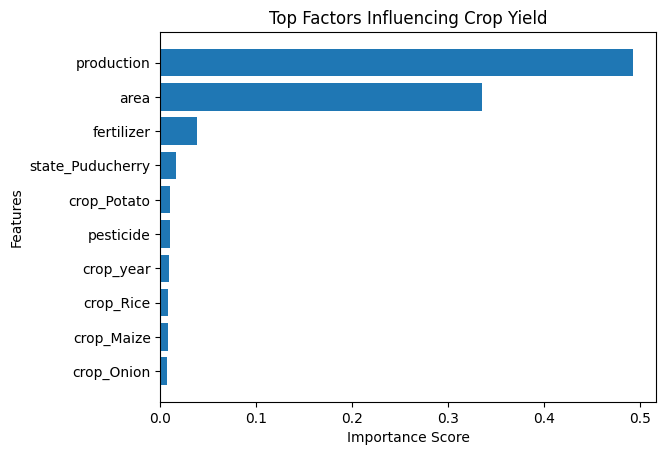

In [55]:
!pip install matplotlib
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()

plt.title("Top Factors Influencing Crop Yield")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()


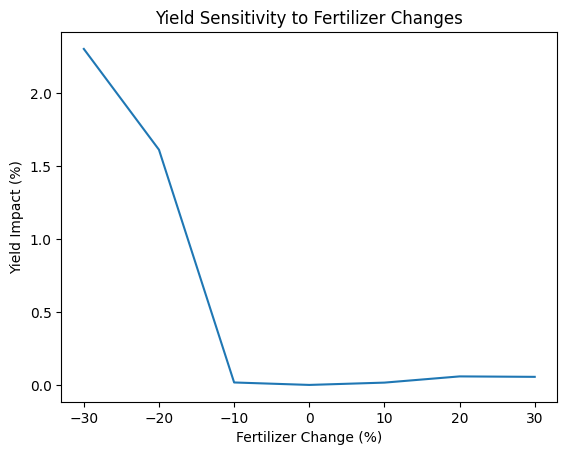

In [56]:
changes = [-30, -20, -10, 0, 10, 20, 30]
impacts = []

for change in changes:
    orig, mod, imp = simulate_yield_change(best_model, sample, "fertilizer", change)
    impacts.append(imp)

plt.figure()
plt.plot(changes, impacts)
plt.title("Yield Sensitivity to Fertilizer Changes")
plt.xlabel("Fertilizer Change (%)")
plt.ylabel("Yield Impact (%)")

plt.show()


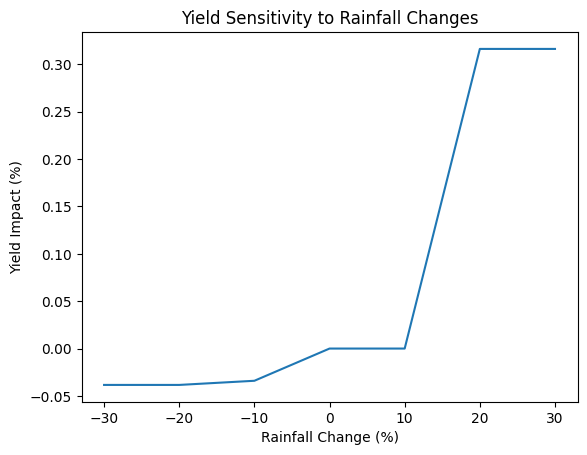

In [57]:
changes = [-30, -20, -10, 0, 10, 20, 30]
impacts = []

for change in changes:
    orig, mod, imp = simulate_yield_change(best_model, sample, "annual_rainfall", change)
    impacts.append(imp)

plt.figure()
plt.plot(changes, impacts)
plt.title("Yield Sensitivity to Rainfall Changes")
plt.xlabel("Rainfall Change (%)")
plt.ylabel("Yield Impact (%)")

plt.show()


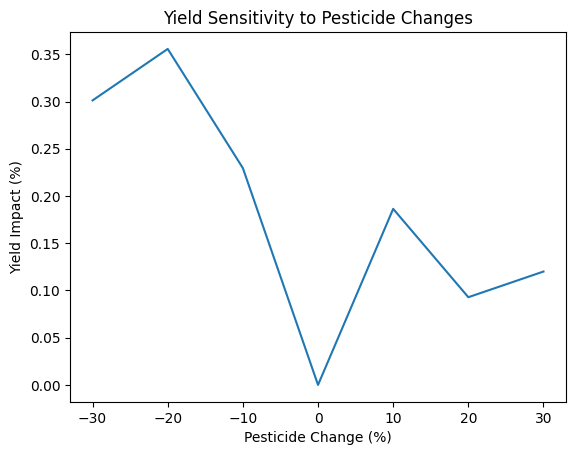

In [58]:
changes = [-30, -20, -10, 0, 10, 20, 30]
impacts = []

for change in changes:
    orig, mod, imp = simulate_yield_change(best_model, sample, "pesticide", change)
    impacts.append(imp)

plt.figure()
plt.plot(changes, impacts)
plt.title("Yield Sensitivity to Pesticide Changes")
plt.xlabel("Pesticide Change (%)")
plt.ylabel("Yield Impact (%)")

plt.show()


In [59]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/random_forest_model.pkl")

print("✅ Model saved successfully")


✅ Model saved successfully


In [60]:
import os
print(os.listdir("../models"))


['feature_columns.pkl', 'random_forest_model.pkl']


In [61]:
import joblib

joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")

print("✅ Feature columns saved")


✅ Feature columns saved
